Estimated number of clusters: 2
Estimated number of noise points: 55


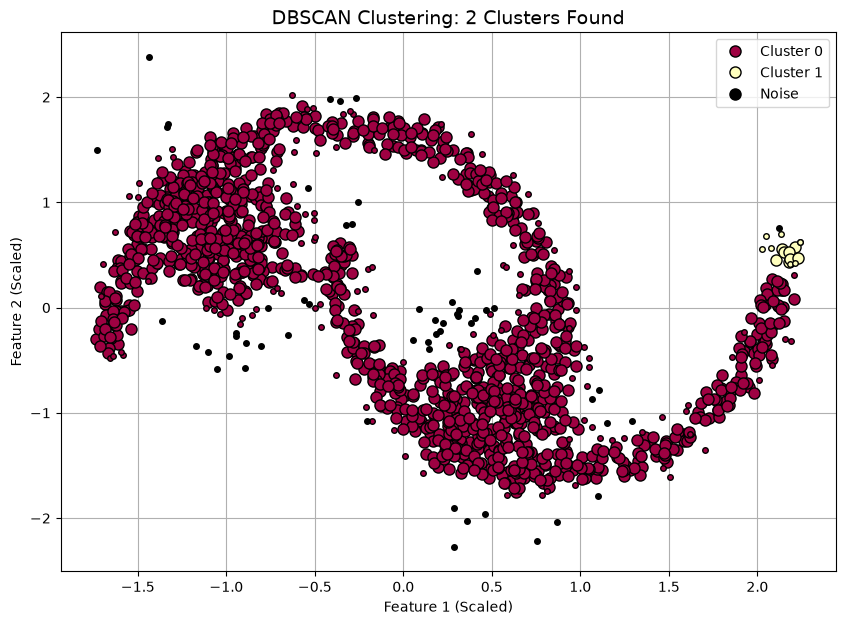

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler

# --- 1. Data Generation ---
# Generating a dataset with different shapes and noise (suitable for DBSCAN)
n_samples = 1500
X_moons, _ = make_moons(n_samples=n_samples // 2, noise=0.05, random_state=0)
X_blobs, _ = make_blobs(n_samples=n_samples // 2, centers=[(-0.5, 0.5), (0.7, -0.2)], cluster_std=0.2, random_state=1)
X = np.vstack([X_moons, X_blobs])

# --- 2. Data Preprocessing (Scaling) ---
# It's crucial to scale the data for distance-based algorithms like DBSCAN
X = StandardScaler().fit_transform(X)

# --- 3. DBSCAN Implementation ---
# Define the parameters. These were chosen based on the structure of the synthetic data.
# Epsilon (eps): max distance for two points to be neighbors
# MinPts (min_samples): minimum number of points to form a dense region
db = DBSCAN(eps=0.15, min_samples=10).fit(X)

# Extract cluster labels. Noise points are assigned a label of -1.
labels = db.labels_

# Number of clusters in labels, ignoring noise if present
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

# --- 4. Visualization of Clusters ---
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

# Define a color map for the clusters, with black reserved for noise
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(10, 7))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise points
        col = [0, 0, 0, 1]

    # Create a mask for points belonging to the current cluster k
    class_member_mask = (labels == k)

    # Plot core points of the cluster
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=8, label=f'Cluster {k}' if k != -1 else 'Noise')

    # Plot border points of the cluster
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=4)

plt.title(f'DBSCAN Clustering: {n_clusters_} Clusters Found', fontsize=14)
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

# --- Visualization Key ---
# Larger dots with black borders are **Core Points**.
# Smaller dots with black borders are **Border Points**.
# Black dots (label -1) are **Noise Points (Outliers)**.